<a href="https://colab.research.google.com/github/dejuakim/PROJECT_aiffel/blob/master/DeepLearning_MainQuest_DKTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 한글 폰트 설정은 한번 실행하고 런타임 재시작을 해야합니다
import matplotlib.pyplot as plt
import platform

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# Colab에서 한글 폰트 설치 및 설정
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
!pip install konlpy pandas numpy matplotlib seaborn --break-system-packages

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from konlpy.tag import Okt
from collections import Counter
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# 모델링 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

# 시드 고정
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.19.0


# STEP 1. 데이터 가져오기

In [ ]:
# 압축 풀기
!unzip -q /content/dkt.zip -d /content/dataset

In [ ]:
import pandas as pd
import os

dataset_dir = "/content/dataset"

# 파일 경로 지정
train_data_path = os.path.join(dataset_dir, "train.csv")
normal_data_path = os.path.join(dataset_dir, "normal_conversation.csv")

# train 데이터 로드
train_data = pd.read_csv(train_data_path)

# normal_conversation 데이터 로드
normal_data = pd.read_csv(normal_data_path)

# normal_data에 idx 컬럼 추가 (train_data의 마지막 idx부터 이어서)
normal_data['idx'] = range(train_data['idx'].max() + 1,
                           train_data['idx'].max() + 1 + len(normal_data))


# 컬럼 순서를 train_data와 동일하게 맞추기 (idx, class, conversation)
normal_data = normal_data[['idx', 'class', 'conversation']]

# 두 데이터프레임 합치기
train_data = pd.concat([train_data, normal_data], ignore_index=True)

print("합친 후 데이터 shape:", train_data.shape)
print("\n클래스 분포:")
print(train_data['class'].value_counts())
print("\n처음 5개 행:")
print(train_data.head())
print("\n마지막 5개 행:")
print(train_data.tail())

합친 후 데이터 shape: (5216, 3)

클래스 분포:
class
일반 대화          1266
기타 괴롭힘 대화      1094
갈취 대화           981
직장 내 괴롭힘 대화     979
협박 대화           896
Name: count, dtype: int64

처음 5개 행:
   idx      class                                       conversation
0    0      협박 대화  지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 ...
1    1      협박 대화  길동경찰서입니다.\n9시 40분 마트에 폭발물을 설치할거다.\n네?\n똑바로 들어 ...
2    2  기타 괴롭힘 대화  너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어.\n그만해. 니들 놀리는거 재미...
3    3      갈취 대화  어이 거기\n예??\n너 말이야 너. 이리 오라고\n무슨 일.\n너 옷 좋아보인다?...
4    4      갈취 대화  저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 ...

마지막 5개 행:
       idx  class                                       conversation
5211  5211  일반 대화  최근에 어떤 앱을 자주 사용해? 나는 운동 기록 앱을 사용하고 있어. 매일 운동극한...
5212  5212  일반 대화  을 사려고 하는데 추천 수 있나요?최근에 출시된 A모델이 좋다고 들었어요.감사합니다...
5213  5213  일반 대화  새 전자제품을 사려고 하는데 추천해주실 수 있나요? 최근에 출시된 A모델이 좋다고 ...
5214  5214  일반 대화  이번 주말에 친구들들신난다함께스릴 에 가기로 했어.타고정말 기대돼!많이놀이기구를 타...
5215  5215  일반 대화  이번 주말에 친구들과 함께 놀이공원에 가기로 했어. 정말 기대

# STEP 2. 데이터 전처리 및 토큰화

영어 vs 한국어 차이:

| 구분 | 영어 | 한국어 |
| :--- | :---: | ---: |
| 토큰화 | 공백 | 형태소 |
| 의미 단위 | 단어 |    어절 + 조사 |
| 변형 | 적음 | 매우 많음 |


특수한 부분은 남기고 없애기

긴 공백도 없애기

In [ ]:
# 전처리 함수
def clean_korean_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'[^가-힣a-zA-Z0-9\s.,!?]', ' ', text)

    # 공백 정리
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [ ]:
# 토큰화 함수
tokenizer_okt = Okt()

def tokenize_korean(text):
    if not isinstance(text, str) or len(text) == 0:
        return []
    try:
        # stem=True → 동사 원형화
        return tokenizer_okt.morphs(text, stem=True)
    except:
        return []

# 전처리 및 토큰화 적용
print("전처리 및 토큰화 진행 중...")
train_data['cleaned_text'] = train_data['conversation'].apply(clean_korean_text)
train_data['tokens'] = train_data['cleaned_text'].apply(tokenize_korean)
train_data['token_length'] = train_data['tokens'].apply(len)

corpus = train_data['tokens']

print("완료!")

전처리 및 토큰화 진행 중...
완료!


In [ ]:
train_data

,idx,class,conversation,cleaned_text,tokens,token_length
0,0,협박 대화,지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 ...,지금 너 스스로를 죽여달라고 애원하는 것인가? 아닙니다. 죄송합니다. 죽을 거면 혼...,"[지금, 너, 스스로, 를, 죽이다, 달라, 고, 애원, 하다, 것, 인가, ?, ...",99
1,1,협박 대화,길동경찰서입니다.\n9시 40분 마트에 폭발물을 설치할거다.\n네?\n똑바로 들어 ...,길동경찰서입니다. 9시 40분 마트에 폭발물을 설치할거다. 네? 똑바로 들어 한번만...,"[길동, 경찰서, 이다, ., 9시, 40분, 마트, 에, 폭발물, 을, 설치, 하...",73
2,2,기타 괴롭힘 대화,너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어.\n그만해. 니들 놀리는거 재미...,너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어. 그만해. 니들 놀리는거 재미없...,"[너, 되게, 귀엽다, 알, 지, ?, 나, 보다, 작다, 남자, 는, 첨, 보다,...",97
3,3,갈취 대화,어이 거기\n예??\n너 말이야 너. 이리 오라고\n무슨 일.\n너 옷 좋아보인다?...,어이 거기 예?? 너 말이야 너. 이리 오라고 무슨 일. 너 옷 좋아보인다? 얘 돈...,"[어이, 거기, 예, ??, 너, 말, 이야, 너, ., 이리, 오라, 고, 무슨,...",48
4,4,갈취 대화,저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 ...,저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 ...,"[저기, 요, 혹시, 날, 이, 너무, 뜨겁다, ?, 저희, 회사, 에서, 이, 선...",186
...,...,...,...,...,...,...
5211,5211,일반 대화,최근에 어떤 앱을 자주 사용해? 나는 운동 기록 앱을 사용하고 있어. 매일 운동극한...,최근에 어떤 앱을 자주 사용해? 나는 운동 기록 앱을 사용하고 있어. 매일 운동극한...,"[최근, 에, 어떻다, 앱, 을, 자주, 사용, 하다, ?, 나, 는, 운동, 기록...",60
5212,5212,일반 대화,을 사려고 하는데 추천 수 있나요?최근에 출시된 A모델이 좋다고 들었어요.감사합니다...,을 사려고 하는데 추천 수 있나요?최근에 출시된 A모델이 좋다고 들었어요.감사합니다...,"[을, 사려, 고, 하다, 추천, 수, 있다, ?, 최근, 에, 출시, 되다, A,...",55
5213,5213,일반 대화,새 전자제품을 사려고 하는데 추천해주실 수 있나요? 최근에 출시된 A모델이 좋다고 ...,새 전자제품을 사려고 하는데 추천해주실 수 있나요? 최근에 출시된 A모델이 좋다고 ...,"[새, 전자제품, 을, 사려, 고, 하다, 추천, 해주다, 수, 있다, ?, 최근,...",72
5214,5214,일반 대화,이번 주말에 친구들들신난다함께스릴 에 가기로 했어.타고정말 기대돼!많이놀이기구를 타...,이번 주말에 친구들들신난다함께스릴 에 가기로 했어.타고정말 기대돼!많이놀이기구를 타...,"[이번, 주말, 에, 친구, 들들, 신나다, 함께, 스릴, 에, 가기, 로, 하다,...",68


### 시퀀스 길이 조절

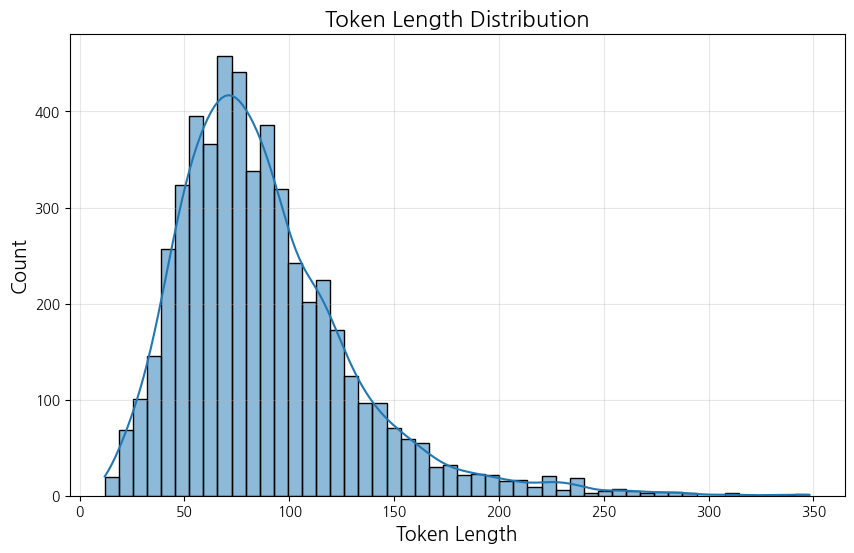

1사분위수 (Q1): 59.0
2사분위수 (Q2, Median): 80.0
3사분위수 (Q3): 109.0
최대 길이: 348


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

# 1) 히스토그램 시각화
plt.figure(figsize=(10,6))
sns.histplot(train_data['token_length'], bins=50, kde=True)
plt.title("Token Length Distribution", fontsize=16)
plt.xlabel("Token Length", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# 2) 사분위수 계산
q1 = train_data['token_length'].quantile(0.25)
q2 = train_data['token_length'].quantile(0.50)  # median
q3 = train_data['token_length'].quantile(0.75)
max_len = train_data['token_length'].max()

# 3) 출력
print(f"1사분위수 (Q1): {q1}")
print(f"2사분위수 (Q2, Median): {q2}")
print(f"3사분위수 (Q3): {q3}")
print(f"최대 길이: {max_len}")

In [ ]:
# token_length 추가 확인
print(train_data['token_length'].quantile(0.90))
print(train_data['token_length'].quantile(0.95))

140.0
166.0


In [ ]:
# max_len 설정
max_len = 250

In [ ]:
sum(train_data['token_length'] > max_len) / len(train_data)

0.00651840490797546

일부 존재하는 긴 문장을 잘라내서 효율 높이기

In [ ]:
train_data[train_data['token_length'] > 250]['conversation'].head()

,conversation
71,자네가 내일 삼송그룹 회장이 192억 탈세를 했다는 사실을 기사로 내보낸다는 기자인...
92,야 신규 너 똑바로 환자 관리 안 하냐? 인수인계 제대로 들은거 맞아? 너 누가 저...
137,신과장 오늘 사직서 쓰고 내일부터 나오지 말게나.\n네? 왜 그러시는거죠? 저 사직...
243,이게 어떻게 된거야.? 엄마 수술은 어떻게 된거냐고\n 엄마가 이제 괜찮다고 해서 ...
244,아빠. 아빠 언제까지 이렇게 누워만 있을거야.\n미안해. 우리 아들. 아빠가 되어서...


### Voca 만들기

In [ ]:
def tokenize(corpus, max_len):
    tokenizer = tf.keras.preprocessing.text.Tokenizer(
        num_words=30000, # 10000 > 20000 > 30000증가
        filters='',
        oov_token="<unk>"
    )
    tokenizer.fit_on_texts(corpus)

    tensor = tokenizer.texts_to_sequences(corpus)

    tensor = tf.keras.preprocessing.sequence.pad_sequences(
        tensor,
        padding='post',
        truncating='post',  # 앞을 남김
        maxlen=max_len)

    print(tensor,tokenizer)
    return tensor, tokenizer

tensor, tokenizer = tokenize(corpus, max_len)

[[  51   10 2254 ...    0    0    0]
 [ 447 1560  104 ...    0    0    0]
 [  10  900 1265 ...    0    0    0]
 ...
 [ 698 4481   20 ...    0    0    0]
 [  70  116    7 ...    0    0    0]
 [  70  116    7 ...    0    0    0]] <keras.src.legacy.preprocessing.text.Tokenizer object at 0x78f48594fe00>


In [ ]:
# class imbalance 확인
print(train_data['class'].value_counts(normalize=True))

class
일반 대화          0.242715
기타 괴롭힘 대화      0.209739
갈취 대화          0.188075
직장 내 괴롭힘 대화    0.187692
협박 대화          0.171779
Name: proportion, dtype: float64


### class 처리 및 분할

In [ ]:
from sklearn.preprocessing import LabelEncoder

X = tensor


# 각 클래스를 숫자로 매핑
label_map = {
    '협박 대화': 0,
    '갈취 대화': 1,
    '직장 내 괴롭힘 대화': 2,
    '기타 괴롭힘 대화': 3,
    '일반 대화': 4
}

y = train_data['class'].map(label_map)

y = np.array(y)

print("X shape:", X.shape)  # (num_samples, 150)
print("y shape:", y.shape)  # (num_samples,)


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y,
    shuffle=True
)

print("데이터셋 분할:")
print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")

# 4) 클래스 분포 확인
print("\n클래스 분포:")
print("Train:", np.bincount(y_train))
print("Validation:", np.bincount(y_val))

X shape: (5216, 250)
y shape: (5216,)
데이터셋 분할:
Train set: 4433 samples (85.0%)
Validation set: 783 samples (15.0%)

클래스 분포:
Train: [ 761  834  832  930 1076]
Validation: [135 147 147 164 190]


In [ ]:
print(train_data['class'].unique())

['협박 대화' '기타 괴롭힘 대화' '갈취 대화' '직장 내 괴롭힘 대화' '일반 대화']


In [ ]:
np.bincount(y_train)

array([ 761,  834,  832,  930, 1076])

In [ ]:
print("Train ratio:", np.bincount(y_train)/len(y_train))
print("Val ratio:", np.bincount(y_val)/len(y_val))

Train ratio: [0.17166704 0.18813445 0.18768328 0.20979021 0.24272502]
Val ratio: [0.17241379 0.18773946 0.18773946 0.20945083 0.24265645]


In [ ]:
# class_weight 적용
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.1650459921156373), 1: np.float64(1.0630695443645084), 2: np.float64(1.065625), 3: np.float64(0.9533333333333334), 4: np.float64(0.8239776951672863)}


# Step 3. 모델 만들기

In [ ]:
def build_strong_lstm(vocab_size, embedding_dim, max_length, num_classes):

    inputs = keras.Input(shape=(max_length,))

    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    )(inputs)

    # BiLSTM
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

    # CNN 추가 (핵심)
    x = layers.Conv1D(128, 3, activation='relu')(x)
    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# def build_lstm_model(vocab_size, embedding_dim, max_length, num_classes):
#     """
#     LSTM 기반 텍스트 분류 모델

#     Args:
#         vocab_size (int): 어휘 크기
#         embedding_dim (int): 임베딩 차원
#         max_length (int): 최대 시퀀스 길이
#         num_classes (int): 클래스 수

#     Returns:
#         keras.Model: 컴파일된 모델
#     """
#     model = keras.Sequential([
#         layers.Embedding(
#             input_dim=vocab_size,
#             output_dim=embedding_dim,
#             input_length=max_length,
#             mask_zero=True,
#             name='embedding'
#         ),

#         layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
#         layers.Bidirectional(layers.LSTM(64)),
#         layers.Dense(64, activation='relu'),
#         layers.Dropout(0.3),

#         layers.Dense(num_classes, activation='softmax', name='output')
#     ])

#     model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=0.001),
#         loss='sparse_categorical_crossentropy',
#         metrics=['accuracy']
#     )

#     return model

In [ ]:
# 하이퍼파라미터 설정
VOCAB_SIZE = min(tokenizer.num_words, len(tokenizer.word_index) + 1)
EMBEDDING_DIM = 200     # 128 → 200
MAX_LENGTH = max_len
NUM_CLASSES = len(np.unique(y))

print("모델 하이퍼파라미터:")
print(f"Vocab Size: {VOCAB_SIZE}")
print(f"Embedding Dim: {EMBEDDING_DIM}")
print(f"Max Length: {MAX_LENGTH}")
print(f"Num Classes: {NUM_CLASSES}")

모델 하이퍼파라미터:
Vocab Size: 12397
Embedding Dim: 200
Max Length: 250
Num Classes: 5


In [ ]:
model = build_lstm_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LENGTH, NUM_CLASSES)
print("LSTM 모델 생성 완료")

LSTM 모델 생성 완료


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
# 모델 학습
BATCH_SIZE = 32
EPOCHS = 30

print("모델 학습 시작...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,  # 추가
    verbose=1
)
print("학습 완료!")

모델 학습 시작...
Epoch 1/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.5637 - loss: 1.0140 - val_accuracy: 0.6897 - val_loss: 0.7120 - learning_rate: 0.0010
Epoch 2/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8358 - loss: 0.4617 - val_accuracy: 0.8582 - val_loss: 0.4036 - learning_rate: 0.0010
Epoch 3/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9292 - loss: 0.2344 - val_accuracy: 0.8416 - val_loss: 0.5431 - learning_rate: 0.0010
Epoch 4/30
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9437 - loss: 0.1845
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9450 - loss: 0.1788 - val_accuracy: 0.8723 - val_loss: 0.4103 - learning_rate: 0.0010
Epoch 5/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9808 - loss: 0.0717 - val_accuracy: 0.8851 - val_loss: 0.3819 - learning_rate: 5.0000e-04
Epoch 6/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0

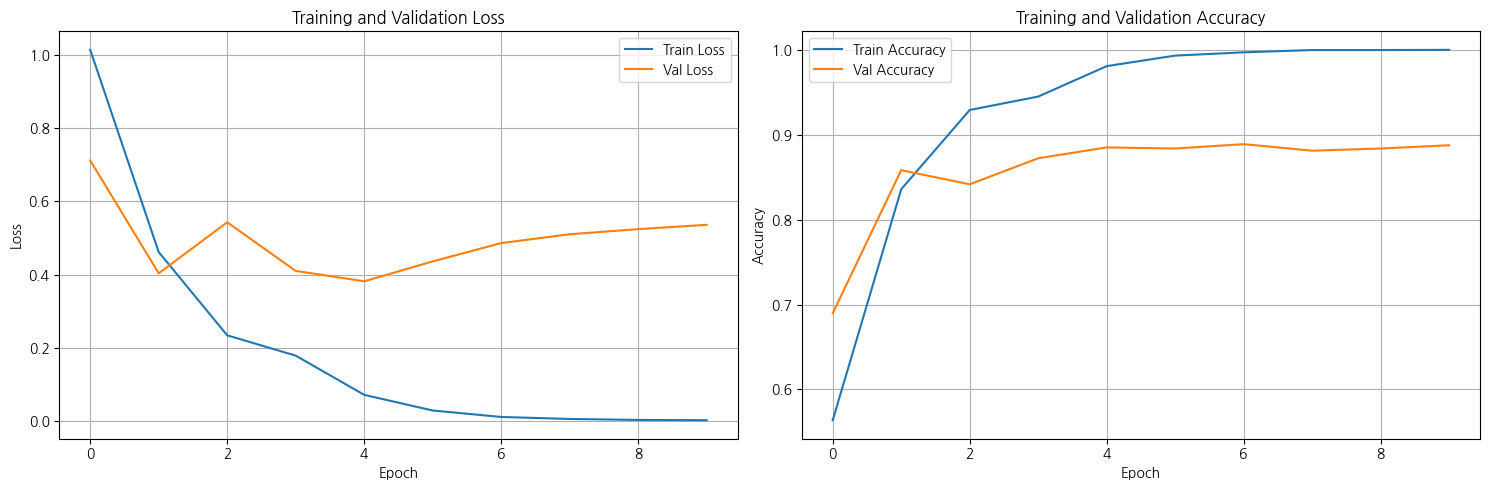

In [ ]:
# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def predict_text(text, model, tokenizer, max_length, class_names):
    """
    새로운 텍스트 예측

    Args:
        text (str): 예측할 텍스트
        model: 학습된 모델
        vocab_builder: 어휘 사전
        max_length (int): 최대 시퀀스 길이
        class_names (list): 클래스 이름 리스트

    Returns:
        dict: 예측 결과
    """
    # 전처리
    cleaned = clean_korean_text(text)
    tokens = tokenize_korean(cleaned)

    # 인덱스 변환
    seq = tokenizer.texts_to_sequences([' '.join(tokens)])

    # 패딩
    padded = pad_sequences(
        seq,
        maxlen=max_length,
        padding='post',
        truncating='post'
        # value 생략 시 0이 패딩 토큰 (기본값)
    )
   # 예측
    pred_proba = model.predict(padded, verbose=0)[0]
    pred_class = np.argmax(pred_proba)

    return {
        'text': text,
        'cleaned_text': cleaned,
        'tokens': tokens,  # 위에서 만든 토큰 리스트
        'predicted_class': class_names[pred_class],
        'confidence': float(pred_proba[pred_class]),
        'probabilities': {
            class_names[i]: float(prob) for i, prob in enumerate(pred_proba)
        }
    }

In [ ]:
# 예측 테스트
test_texts = [
    "말 안들으면 혼날 줄 알아",
    "돈 내놔 안그러면 큰일난다",
    "또 실수했어? 정말 못쓰겠네",
    "넌 정말 쓸모없는 인간이야"
]

class_names = [
    '협박',
    '갈취',
    '직장내괴롭힘',
    '기타 괴롭힘',
    '일반'
]

print("=" * 80)
print("예측 테스트")
print("=" * 80)

max_length = max_len

for i, text in enumerate(test_texts, 1):
    result = predict_text(text, model, tokenizer, max_length, class_names)

    print(f"\n[테스트 {i}]")
    print(f"입력: {result['text']}")
    print(f"예측: {result['predicted_class']} (신뢰도: {result['confidence']:.4f})")
    print("확률:")
    for class_name, prob in result['probabilities'].items():
        print(f"  {class_name}: {prob:.4f}")

예측 테스트

[테스트 1]
입력: 말 안들으면 혼날 줄 알아
예측: 갈취 (신뢰도: 0.9512)
확률:
  협박: 0.0185
  갈취: 0.9512
  직장내괴롭힘: 0.0009
  기타 괴롭힘: 0.0294
  일반: 0.0000

[테스트 2]
입력: 돈 내놔 안그러면 큰일난다
예측: 갈취 (신뢰도: 0.9949)
확률:
  협박: 0.0029
  갈취: 0.9949
  직장내괴롭힘: 0.0001
  기타 괴롭힘: 0.0021
  일반: 0.0000

[테스트 3]
입력: 또 실수했어? 정말 못쓰겠네
예측: 일반 (신뢰도: 0.8471)
확률:
  협박: 0.0557
  갈취: 0.0132
  직장내괴롭힘: 0.0727
  기타 괴롭힘: 0.0114
  일반: 0.8471

[테스트 4]
입력: 넌 정말 쓸모없는 인간이야
예측: 직장내괴롭힘 (신뢰도: 0.3785)
확률:
  협박: 0.0692
  갈취: 0.0409
  직장내괴롭힘: 0.3785
  기타 괴롭힘: 0.1778
  일반: 0.3335


# 캐글 제출용 코드

- test데이터셋을 불러와서 idx를 넣는다
- submission.csv로 저장한다


In [ ]:
test_data_path = os.path.join(dataset_dir, "test.csv")
submission_data_path = os.path.join(dataset_dir, "submission.csv")

In [ ]:
# 2. test.csv 불러오기
test_data = pd.read_csv(test_data_path, encoding="utf-8")
test_data = test_data.set_index("idx")

submission = pd.read_csv(submission_data_path)

# id 기준 정렬(혹시나 섞여 있을 수 있으니)
submission = submission.sort_values("file_name").reset_index(drop=True)

In [ ]:
submission = submission.rename(columns={'file_name': 'idx'})

In [ ]:
# submission의 id 순서에 맞춰서 test_data에서 text 가져오기
ids = submission["idx"].tolist()                 # 예: ['t_000', 't_001', ...]

texts = [test_data.loc[i, "conversation"] for i in ids]

In [ ]:
test_data

,conversation
idx,
t_000,아가씨 담배한갑주소 네 4500원입니다 어 네 지갑어디갔지 에이 버스에서 잃어버렸나...
t_001,우리팀에서 다른팀으로 갈 사람 없나? 그럼 영지씨가 가는건 어때? 네? 제가요? ...
t_002,너 오늘 그게 뭐야 네 제가 뭘 잘못했나요.? 제대로 좀 하지 네 똑바로 좀 하지 ...
t_003,이거 들어바 와 이 노래 진짜 좋다 그치 요즘 이 것만 들어 진짜 너무 좋다 내가 ...
t_004,아무튼 앞으로 니가 내 와이파이야. .응 와이파이 온. 켰어. 반말? 주인님이라고도...
...,...
t_495,미나씨 휴가 결제 올리기 전에 저랑 상의하라고 말한거 기억해요? 네 합니다. 보고서...
t_496,교수님 제 논문에 제 이름이 없나요? 아 무슨 논문말이야? 지난 번 냈던 논문이...
t_497,야 너 네 저요? 그래 너 왜요 돈좀 줘봐 돈 없어요 돈이 왜 없어 지갑은 폼이...


In [ ]:
# -------------------------------------------------
# 4. Tokenizer로 시퀀스 변환 + 패딩
#    (tokenizer는 이미 train에서 fit_on_texts(corpus) 된 상태라고 가정)
# -------------------------------------------------
sequences = tokenizer.texts_to_sequences(texts)

In [ ]:
X_test = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [ ]:
pred_proba = model.predict(X_test, batch_size=32, verbose=1)
pred_indices = np.argmax(pred_proba, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [ ]:
pred_labels = pred_indices
pred_labels

array([0, 0, 2, 1, 1, 0, 2, 0, 2, 1, 0, 0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 1, 0, 2, 2, 0, 1, 2, 1, 0, 2, 2, 0, 3, 0, 0, 0, 1, 0, 1, 2, 1,
       0, 2, 0, 0, 2, 0, 1, 0, 2, 2, 2, 0, 0, 0, 0, 0, 3, 0, 0, 0, 2, 0,
       2, 0, 2, 0, 1, 2, 3, 2, 0, 2, 2, 0, 2, 4, 1, 0, 0, 0, 0, 2, 1, 3,
       1, 2, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 2, 2, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 1, 0, 2, 2, 1, 0, 0, 0, 1, 0, 0, 2, 2, 3, 0, 0, 0,
       2, 0, 1, 0, 0, 0, 1, 2, 3, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 1, 0, 2, 2, 2, 0, 0, 2, 0, 0, 2, 2, 1, 1, 1, 0, 2, 2, 0, 0, 3,
       0, 2, 0, 1, 2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 3, 1, 0, 1, 0, 0, 0,
       2, 2, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 3, 0, 0, 0,
       1, 4, 0, 0, 0, 0, 2, 0, 1, 0, 0, 2, 3, 0, 1, 0, 0, 0, 0, 0, 0, 2,
       0, 2, 4, 1, 2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 1, 1, 1, 0,
       0, 0, 0, 0, 2, 2, 0, 2, 0, 2, 1, 0, 2, 2, 2, 2, 1, 0, 0, 2, 2, 2,
       1, 2, 0, 0, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 2,

In [ ]:
submission["class"] = pred_labels

In [ ]:
save_path = "/content/my_submission_01.csv"
submission.to_csv(save_path, index=False)

print("저장 완료:", save_path)
submission.head()

저장 완료: /content/my_submission_01.csv


,idx,class
0,t_000,0
1,t_001,0
2,t_002,2
3,t_003,1
4,t_004,1


점수 0.42200

### 확인코드

In [ ]:
print(test_data.columns)

Index(['conversation'], dtype='object')


In [ ]:
import pandas as pd

rows = []

for i, text in enumerate(test_data["conversation"]):
    tid = f"t_{i:03d}"

    result = predict_text(
        text, model, tokenizer, max_length, class_names
    )

    rows.append({
        "id": tid,
        "text": text,
        "predicted_class": result["predicted_class"],
        "confidence": float(result["confidence"])
    })

test_pred_df = pd.DataFrame(rows)
test_pred_df.head()

,id,text,predicted_class,confidence
0,t_000,아가씨 담배한갑주소 네 4500원입니다 어 네 지갑어디갔지 에이 버스에서 잃어버렸나...,갈취,0.939253
1,t_001,우리팀에서 다른팀으로 갈 사람 없나? 그럼 영지씨가 가는건 어때? 네? 제가요? ...,직장내괴롭힘,0.912934
2,t_002,너 오늘 그게 뭐야 네 제가 뭘 잘못했나요.? 제대로 좀 하지 네 똑바로 좀 하지 ...,직장내괴롭힘,0.987334
3,t_003,이거 들어바 와 이 노래 진짜 좋다 그치 요즘 이 것만 들어 진짜 너무 좋다 내가 ...,일반,0.869463
4,t_004,아무튼 앞으로 니가 내 와이파이야. .응 와이파이 온. 켰어. 반말? 주인님이라고도...,직장내괴롭힘,0.759212


## 모델 개선
BiLSTM + CNN hybrid

Dropout 강화

Global pooling

class_weight 적용

learning rate 안정화

In [ ]:
from tensorflow.keras import layers, regularizers
import tensorflow as tf
import keras

def build_upgraded_baseline(vocab_size, embedding_dim, max_length, num_classes):

    model = keras.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_length
        ),

        # 수정 1 & 2: 전체 시퀀스 반환 및 LSTM 내부 드롭아웃
        layers.Bidirectional(layers.LSTM(
            128,
            return_sequences=True,  # 다음 풀링 층으로 전체 시퀀스를 넘겨줌
            dropout=0.3,            # 입력에 대한 드롭아웃
            recurrent_dropout=0.3   # 순환 상태(Hidden State)에 대한 드롭아웃
        )),

        # 수정 3: Global Max Pooling (핵심 키워드 추출)
        layers.GlobalMaxPooling1D(),

        layers.Dropout(0.5),

        # 수정 4: L2 정규화(Regularization) 추가
        layers.Dense(
            64,
            activation='relu',
            kernel_regularizer=regularizers.l2(0.01) # 가중치 감쇠 (Weight Decay)
        ),

        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ])

    # 수정 5: 일반 Adam 대신 AdamW 사용 (과적합 방지에 더 효과적)
    optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.004)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
max_len = 200

VOCAB_SIZE = min(tokenizer.num_words, len(tokenizer.word_index) + 1)
EMBEDDING_DIM = 128
MAX_LENGTH = max_len
NUM_CLASSES = len(np.unique(y))

In [ ]:
model = build_best_baseline(VOCAB_SIZE, EMBEDDING_DIM, MAX_LENGTH, NUM_CLASSES)
print("LSTM 모델 생성 완료")
model.summary()

LSTM 모델 생성 완료


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.1650459921156373), 1: np.float64(1.0630695443645084), 2: np.float64(1.065625), 3: np.float64(0.9533333333333334), 4: np.float64(0.8239776951672863)}


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.4157 - loss: 1.3257 - val_accuracy: 0.6309 - val_loss: 0.8461 - learning_rate: 0.0010
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7137 - loss: 0.7560 - val_accuracy: 0.7152 - val_loss: 0.6523 - learning_rate: 0.0010
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8166 - loss: 0.4879 - val_accuracy: 0.7829 - val_loss: 0.5956 - learning_rate: 0.0010
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8863 - loss: 0.3752 - val_accuracy: 0.8212 - val_loss: 0.5407 - learning_rate: 0.0010
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9208 - loss: 0.2672 - val_accuracy: 0.7893 - val_loss: 0.6590 - learning_rate: 0.0010
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9434 - loss: 0.1936 - val_accuracy: 0.8289 - val_loss: 0.5880 - learning_rate: 0.0010
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9659 - loss: 0.

In [ ]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(X_val), axis=1)
print(classification_report(y_val, y_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

           0       0.74      0.64      0.69       135
           1       0.80      0.71      0.76       147
           2       0.88      0.90      0.89       147
           3       0.67      0.79      0.72       164
           4       0.98      1.00      0.99       190

    accuracy                           0.82       783
   macro avg       0.82      0.81      0.81       783
weighted avg       0.82      0.82      0.82       783



In [ ]:
# test 데이터 로드
test_data_path = os.path.join(dataset_dir, "test.csv")
submission_data_path = os.path.join(dataset_dir, "submission.csv")

test_data = pd.read_csv(test_data_path, encoding="utf-8")
test_data = test_data.set_index("idx")

submission = pd.read_csv(submission_data_path)

submission = submission.rename(columns={'file_name': 'idx'})
submission = submission.sort_values("idx").reset_index(drop=True)

ids = submission["idx"].tolist()

# 전처리 + 토큰화 동일하게
processed_texts = []

for i in ids:
    text = test_data.loc[i, "conversation"]
    cleaned = clean_korean_text(text)
    tokens = tokenize_korean(cleaned)
    processed_texts.append(' '.join(tokens))

# 시퀀스 변환
sequences = tokenizer.texts_to_sequences(processed_texts)

X_test = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

# 예측
pred_proba = model.predict(X_test, batch_size=32, verbose=1)
pred_indices = np.argmax(pred_proba, axis=1)

# 제출 파일
submission["class"] = pred_indices

save_path = "/content/my_submission_08.csv"
submission.to_csv(save_path, index=False)

print("저장 완료:", save_path)
submission.head()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
저장 완료: /content/my_submission_08.csv


,idx,class
0,t_000,3
1,t_001,2
2,t_002,2
3,t_003,1
4,t_004,0


점수 0.58000

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam

# 하이퍼파라미터 세팅 (이 값들을 바꿔가며 실험 기록!)
vocab_size = 20000    # 단어 사전 크기
embedding_dim = 256   # 실험 포인트 3: 임베딩 차원 (64, 128, 256)
lstm_units = 128       # 실험 포인트 2: LSTM 유닛 수 (32, 64, 128)
dropout_rate = 0.5    # 실험 포인트 1: 드롭아웃 비율 (0.3 ~ 0.5)

model = Sequential()

# 1. 임베딩 레이어
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=150))

# 2. 첫 번째 Bi-LSTM (다음 LSTM으로 넘겨주기 위해 return_sequences=True 필수)
model.add(Bidirectional(LSTM(lstm_units, return_sequences=True,
                             dropout=0.3, recurrent_dropout=0.3))) # LSTM 내부 드롭아웃 적용

# 3. 두 번째 Bi-LSTM
model.add(Bidirectional(LSTM(lstm_units,
                             dropout=0.3, recurrent_dropout=0.3)))

# 실험 포인트 1: Dense로 가기 전 드롭아웃 레이어 추가
model.add(Dropout(dropout_rate))

# 4. Dense 레이어 (다중 분류이므로 5개 클래스, 활성화 함수는 softmax)
model.add(Dense(5, activation='softmax'))

# 실험 포인트 4: 옵티마이저와 학습률 변경
optimizer = Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.1650459921156373), 1: np.float64(1.0630695443645084), 2: np.float64(1.065625), 3: np.float64(0.9533333333333334), 4: np.float64(0.8239776951672863)}


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.7681 - loss: 0.6459 - val_accuracy: 0.8135 - val_loss: 0.5068 - learning_rate: 0.0010
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.8807 - loss: 0.3872 - val_accuracy: 0.8467 - val_loss: 0.4291 - learning_rate: 0.0010
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9235 - loss: 0.2587 - val_accuracy: 0.8352 - val_loss: 0.5480 - learning_rate: 0.0010
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.9465 - loss: 0.1879 - val_accuracy: 0.8352 - val_loss: 0.5764 - learning_rate: 0.0010
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9619 - loss: 0.1345
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
139/139 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9666 - loss: 0.1200 - val_accuracy: 0.8404 - val_loss: 0.5836 - learning_rate: 0.0010
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


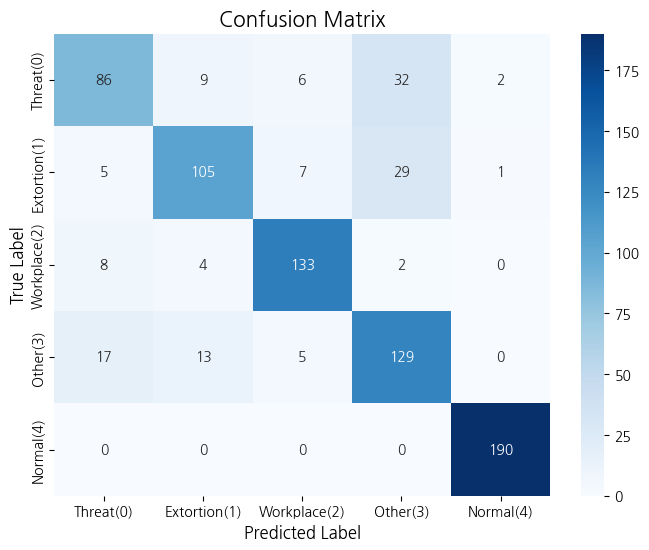

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

labels = ['Threat(0)', 'Extortion(1)', 'Workplace(2)', 'Other(3)', 'Normal(4)']

# 혼동 행렬 계산
cm = confusion_matrix(y_val, y_pred)

# 히트맵 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. 파일 불러오기 및 제출 폼 정렬
test_data = pd.read_csv(test_data_path, encoding="utf-8")
test_data = test_data.set_index("idx")

submission = pd.read_csv(submission_data_path)
if 'file_name' in submission.columns:
    submission = submission.rename(columns={'file_name': 'idx'})
submission = submission.sort_values("idx").reset_index(drop=True)

# 2. 텍스트 추출 및 전처리 (매우 중요 ⭐️)
# ids 순서대로 텍스트를 가져오면서, 학습 때 썼던 clean_korean_text 함수를 똑같이 적용합니다.
ids = submission["idx"].tolist()
texts = [clean_korean_text(test_data.loc[i, "conversation"]) for i in ids]

# 3. Keras Tokenizer 처리 및 패딩
# (HuggingFace 문법 대신 우리가 썼던 Keras 문법 사용, 길이는 학습 때와 동일한 150으로!)
sequences = tokenizer.texts_to_sequences(texts)
X_test = pad_sequences(
    sequences,
    maxlen=max_len,  # 128이 아니라 학습 모델과 동일하게 150으로 맞춰야 합니다.
    padding='post',
    truncating='post'
)

# 4. Keras 모델 예측 (trainer가 아닌 model.predict 사용)
print("테스트 데이터 예측 중...")
pred_proba = model.predict(X_test, batch_size=32, verbose=1)
pred_indices = np.argmax(pred_proba, axis=1)

# 5. 제출 파일 저장
submission["class"] = pred_indices

save_path = "/content/my_submission_10.csv"
submission.to_csv(save_path, index=False)

print("\n저장 완료:", save_path)
display(submission.head())

테스트 데이터 예측 중...
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 440ms/step

저장 완료: /content/my_submission_10.csv


,idx,class
0,t_000,3
1,t_001,3
2,t_002,2
3,t_003,3
4,t_004,4


점수 0.52600

In [ ]:
import pandas as pd

sub_check = pd.read_csv("/content/my_submission_10.csv")

# 만약 타겟 컬럼 이름이 'class'라면:
print(sub_check['class'].value_counts())
# 만약 'target'이라면:
# print(sub_check['target'].value_counts())

class
0    197
3    172
2     63
4     37
1     31
Name: count, dtype: int64


## Transformer로 변경

In [ ]:
!pip install transformers datasets

In [ ]:
!pip install -U transformers

In [ ]:
# 토크나이저
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("klue/roberta-base")

In [ ]:
# encode
def encode_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=250,
        return_tensors='pt'
    )

In [ ]:
X_text = train_data['conversation'].apply(clean_korean_text)
y = train_data['class'].map(label_map).values

In [ ]:
from sklearn.model_selection import train_test_split

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# 데이터
X_train_enc = encode_data(X_train_text)
X_val_enc = encode_data(X_val_text)

In [ ]:
# 모델
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "klue/roberta-base",
    num_labels=5
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Trainer
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    logging_dir="./logs",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True, # 가장 성능 좋은 모델 복원
    metric_for_best_model="f1",
    weight_decay=0.01,           # 과적합 방지 규제 추가
    warmup_ratio=0.1             # 안정적인 학습 시작을 위한 웜업
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# Dataset 변환
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(X_train_enc, y_train)
val_dataset = Dataset(X_val_enc, y_val)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

In [ ]:
# 학습
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    # 2 에폭 동안 F1 점수가 안 오르면 조기 종료
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.310930,0.903257,0.898716
2,0.359182,0.256330,0.931034,0.927505
3,0.359182,0.293378,0.930077,0.926254
4,0.092158,0.332397,0.934866,0.931399
5,0.092158,0.340650,0.931992,0.928468


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1305, training_loss=0.18127044151569235, metrics={'train_runtime': 443.387, 'train_samples_per_second': 47.047, 'train_steps_per_second': 2.943, 'total_flos': 2680002173730000.0, 'train_loss': 0.18127044151569235, 'epoch': 5.0})

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, classification_report

predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

from sklearn.metrics import f1_score
print("F1:", f1_score(y_val, y_pred, average='macro'))

F1: 0.9313990082982361


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# ---------------------------------------------------------
# 1. 토크나이저 세팅 (전처리 함수 삭제! 날것 그대로 사용)
# ---------------------------------------------------------
MODEL_NAME = "klue/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 250

def encode_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

# ---------------------------------------------------------
# 2. 학습 데이터 전처리 및 분할
# ---------------------------------------------------------
print("학습 데이터 준비 중 (순정 데이터)...")
# clean_korean_text 적용 없이 conversation 컬럼 원본 그대로 사용
X_text = train_data['conversation']
y = train_data['class'].map(label_map).values

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.20, random_state=42, stratify=y
)

X_train_enc = encode_data(X_train_text)
X_val_enc = encode_data(X_val_text)

# PyTorch Dataset 클래스
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

train_dataset = CustomDataset(X_train_enc, y_train)
val_dataset = CustomDataset(X_val_enc, y_val)

# ---------------------------------------------------------
# 3. 모델 세팅 및 학습 (조기 종료 해제)
# ---------------------------------------------------------
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,          # 4번 꽉 채워서 충분히 학습!
    logging_dir="./logs",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True, # 4번 중 F1이 가장 높은 모델 자동 복원
    metric_for_best_model="f1",
    weight_decay=0.01,
    warmup_ratio=0.1
)

# EarlyStoppingCallback 제거하여 중간에 강제 종료되지 않도록 함
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("모델 학습 시작 (순정 모드)...")
trainer.train()

# ---------------------------------------------------------
# 4. 테스트 데이터 예측 및 제출 파일 생성
# ---------------------------------------------------------
print("테스트 데이터 불러오는 중...")
test_data = pd.read_csv(test_data_path, encoding="utf-8")
test_data = test_data.set_index("idx")

submission = pd.read_csv(submission_data_path)
if 'file_name' in submission.columns:
    submission = submission.rename(columns={'file_name': 'idx'})
submission = submission.sort_values("idx").reset_index(drop=True)

ids = submission["idx"].tolist()

print("테스트 데이터 토큰화 중 (순정 데이터)...")
# 테스트 데이터 역시 전처리 없이 바로 가져옴
test_texts = pd.Series([test_data.loc[i, "conversation"] for i in ids])

# 토큰화
test_encodings = encode_data(test_texts)
test_dataset = CustomDataset(test_encodings) # labels=None

print("최종 모델로 테스트 데이터 예측 중...")
predictions = trainer.predict(test_dataset)
pred_indices = np.argmax(predictions.predictions, axis=1)

submission["class"] = pred_indices

# 파일명 14 버전으로 업데이트
save_path = "/content/my_submission_14.csv"
submission.to_csv(save_path, index=False)

print("\n저장 완료:", save_path)
display(submission.head())

학습 데이터 준비 중 (순정 데이터)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprec

모델 학습 시작 (순정 모드)...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.412494,0.874521,0.865018
2,0.464641,0.231056,0.929119,0.925481
3,0.464641,0.310714,0.929119,0.925490
4,0.089619,0.299602,0.931034,0.927093


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

테스트 데이터 불러오는 중...
테스트 데이터 토큰화 중 (순정 데이터)...
최종 모델로 테스트 데이터 예측 중...



🎉 저장 완료: /content/my_submission_14.csv


,idx,class
0,t_000,1
1,t_001,2
2,t_002,2
3,t_003,3
4,t_004,3


점수 0.74000

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# ---------------------------------------------------------
# 1. 모델 및 토크나이저 세팅 (KcBERT로 변경)
# ---------------------------------------------------------
# 한국어 온라인 댓글을 학습한 beomi/kcbert-base 사용
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 250

def encode_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

# ---------------------------------------------------------
# 2. 데이터 준비
# ---------------------------------------------------------
X_text = train_data['conversation']
y = train_data['class'].map(label_map).values

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.20, random_state=42, stratify=y
)

X_train_enc = encode_data(X_train_text)
X_val_enc = encode_data(X_val_text)

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

train_dataset = CustomDataset(X_train_enc, y_train)
val_dataset = CustomDataset(X_val_enc, y_val)

# ---------------------------------------------------------
# 3. 모델 세팅 및 학습
# ---------------------------------------------------------
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./results_kcbert", # 폴더명 구분
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    logging_dir="./logs_kcbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.01,
    warmup_ratio=0.1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print(f"[{MODEL_NAME}] 모델 학습 시작...")
trainer.train()

# ---------------------------------------------------------
# 4. 테스트 데이터 예측 및 제출
# ---------------------------------------------------------
test_data = pd.read_csv(test_data_path, encoding="utf-8").set_index("idx")
submission = pd.read_csv(submission_data_path)
if 'file_name' in submission.columns:
    submission = submission.rename(columns={'file_name': 'idx'})
submission = submission.sort_values("idx").reset_index(drop=True)

ids = submission["idx"].tolist()
test_texts = pd.Series([test_data.loc[i, "conversation"] for i in ids])

print("테스트 데이터 예측 중...")
test_encodings = encode_data(test_texts)
test_dataset = CustomDataset(test_encodings)

predictions = trainer.predict(test_dataset)
pred_indices = np.argmax(predictions.predictions, axis=1)

submission["class"] = pred_indices

# 파일명 15 버전으로 저장
save_path = "/content/my_submission_15_kcbert.csv"
submission.to_csv(save_path, index=False)

print(f"\n저장 완료: {save_path}")
display(submission.head())

config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

테스트 데이터 예측 중...



🎉 저장 완료: /content/my_submission_15_kcbert.csv


,idx,class
0,t_000,1
1,t_001,2
2,t_002,2
3,t_003,3
4,t_004,3


점수 0.75600

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# ---------------------------------------------------------
# 1. 모델 및 토크나이저 세팅 (KcBERT)
# ---------------------------------------------------------
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 250

def encode_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

# ---------------------------------------------------------
# 2. 데이터 준비 및 클래스 가중치 계산
# ---------------------------------------------------------
X_text = train_data['conversation']
y = train_data['class'].map(label_map).values

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.15, random_state=42, stratify=y # 주아님 설정(15%) 반영
)

# 클래스별 가중치 계산 루틴
counts = np.bincount(y_train)
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts) # 가중치 평균을 1로 정규화
class_weights = torch.tensor(weights, dtype=torch.float).to("cuda")

print("-" * 30)
print(f"클래스별 샘플 수: {counts}")
print(f"적용될 학습 가중치: {weights}")
print("-" * 30)

X_train_enc = encode_data(X_train_text)
X_val_enc = encode_data(X_val_text)

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

train_dataset = CustomDataset(X_train_enc, y_train)
val_dataset = CustomDataset(X_val_enc, y_val)

# ---------------------------------------------------------
# 3. WeightedTrainer 정의 (손실 함수 커스텀)
# ---------------------------------------------------------
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # 가중치가 적용된 CrossEntropyLoss로 소수 클래스 집중 케어
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# ---------------------------------------------------------
# 4. 모델 학습 설정 및 실행
# ---------------------------------------------------------
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./results_weighted",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,          # 가중치 학습 시에는 조금 더 충분히(5회) 돌려봅니다.
    logging_dir="./logs_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.01,
    warmup_ratio=0.1
)

# 커스텀 Trainer 사용
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print(f" [{MODEL_NAME}] Weighted Training 시작...")
trainer.train()

# ---------------------------------------------------------
# 5. 테스트 데이터 예측 및 제출
# ---------------------------------------------------------
test_data = pd.read_csv(test_data_path, encoding="utf-8").set_index("idx")
submission = pd.read_csv(submission_data_path)
if 'file_name' in submission.columns:
    submission = submission.rename(columns={'file_name': 'idx'})
submission = submission.sort_values("idx").reset_index(drop=True)

ids = submission["idx"].tolist()
test_texts = pd.Series([test_data.loc[i, "conversation"] for i in ids])

print("최종 테스트 데이터 예측 중...")
test_encodings = encode_data(test_texts)
test_dataset = CustomDataset(test_encodings)

predictions = trainer.predict(test_dataset)
pred_indices = np.argmax(predictions.predictions, axis=1)

submission["class"] = pred_indices

# 파일명 16 버전으로 저장
save_path = "/content/my_submission_16_final_weighted.csv"
submission.to_csv(save_path, index=False)

print(f"\n모든 과정 완료! 저장 경로: {save_path}")
display(submission['class'].value_counts()) # 예측 분포 확인용

------------------------------
📊 클래스별 샘플 수: [ 761  834  832  930 1076]
⚖️ 적용될 학습 가중치: [1.14872229 1.04817465 1.05069431 0.93997598 0.81243277]
------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

🚀 [beomi/kcbert-base] Weighted Training 시작...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.313133,0.900383,0.895244
2,0.443902,0.322095,0.918263,0.915189
3,0.443902,0.330770,0.931034,0.928000
4,0.071892,0.390186,0.925926,0.922338
5,0.071892,0.370864,0.937420,0.934881


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

최종 테스트 데이터 예측 중...



🎉 모든 과정 완료! 저장 경로: /content/my_submission_16_final_weighted.csv


,count
class,
3,160
2,115
0,107
1,103
4,15


점수 0.73600

가중치의 부작용으로 보임. 가중치를 조정해서 다시 돌려봄

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# 1. 모델 및 토크나이저 세팅
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 250

def encode_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

# 2. 데이터 준비 및 "부드러운" 가중치 계산
X_text = train_data['conversation']
y = train_data['class'].map(label_map).values

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.15, random_state=42, stratify=y
)

# 가중치 격차를 줄이기 위해 로그 스케일 적용 (Smoothing)
counts = np.bincount(y_train)
# 1.0/counts 대신 log를 사용하여 가중치가 너무 튀지 않게 조절합니다.
weights = 1.0 / (np.log1p(counts))
weights = weights / weights.sum() * len(counts)
class_weights = torch.tensor(weights, dtype=torch.float).to("cuda")

print("-" * 30)
print(f"클래스별 샘플 수: {counts}")
print(f"부드럽게 조정된 가중치: {weights}")
print("-" * 30)

X_train_enc = encode_data(X_train_text)
X_val_enc = encode_data(X_val_text)

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

train_dataset = CustomDataset(X_train_enc, y_train)
val_dataset = CustomDataset(X_val_enc, y_val)

# 3. WeightedTrainer 정의
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# 4. 모델 학습 설정 및 실행
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./results_smooth_weighted",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    logging_dir="./logs_smooth",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.01,
    warmup_ratio=0.1
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print(f"[{MODEL_NAME}] Smooth Weighted Training 시작...")
trainer.train()

# 5. 테스트 데이터 예측 및 제출
test_data = pd.read_csv(test_data_path, encoding="utf-8").set_index("idx")
submission = pd.read_csv(submission_data_path)
if 'file_name' in submission.columns:
    submission = submission.rename(columns={'file_name': 'idx'})
submission = submission.sort_values("idx").reset_index(drop=True)

ids = submission["idx"].tolist()
test_texts = pd.Series([test_data.loc[i, "conversation"] for i in ids])

print("최종 테스트 데이터 예측 중...")
test_encodings = encode_data(test_texts)
test_dataset = CustomDataset(test_encodings)

predictions = trainer.predict(test_dataset)
pred_indices = np.argmax(predictions.predictions, axis=1)

submission["class"] = pred_indices

# 파일명 17 버전으로 저장
save_path = "/content/my_submission_17_smooth_weighted.csv"
submission.to_csv(save_path, index=False)

print(f"\n저장 완료: {save_path}")
print("\n[예측 분포 확인]")
print(submission['class'].value_counts())

------------------------------
📊 클래스별 샘플 수: [ 761  834  832  930 1076]
⚖️ 부드럽게 조정된 가중치: [1.02159701 1.00770449 1.00806383 0.99166267 0.97097201]
------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

🚀 [beomi/kcbert-base] Smooth Weighted Training 시작...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.270867,0.923372,0.918467
2,0.429588,0.236126,0.934866,0.931275
3,0.429588,0.338523,0.929757,0.926774
4,0.067140,0.363468,0.924649,0.920894
5,0.067140,0.389224,0.928480,0.925247


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

최종 테스트 데이터 예측 중...



🎉 저장 완료: /content/my_submission_17_smooth_weighted.csv

[예측 분포 확인]
class
3    150
1    118
2    118
0    104
4     10
Name: count, dtype: int64


임계값(Threshold)을 조절해보기로 함

In [ ]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer

# 1. 모델 및 토크나이저 로드 (가장 최근 학습된 모델 사용)
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained("./results_smooth_weighted/checkpoint-834", num_labels=5) # 최신 체크포인트 경로로 수정해주세요!

# 2. 테스트 데이터 준비
test_data = pd.read_csv(test_data_path, encoding="utf-8").set_index("idx")
submission = pd.read_csv(submission_data_path)
if 'file_name' in submission.columns:
    submission = submission.rename(columns={'file_name': 'idx'})
submission = submission.sort_values("idx").reset_index(drop=True)

ids = submission["idx"].tolist()
test_texts = pd.Series([test_data.loc[i, "conversation"] for i in ids])

# 3. 예측 수행 (확률값 추출)
def get_predictions(texts):
    inputs = tokenizer(texts.tolist(), padding=True, truncation=True, max_length=250, return_tensors="pt").to("cuda")
    model.to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1) # 확률값으로 변환
    return probs.cpu().numpy()

print("테스트 데이터 확률값 추출 중...")
all_probs = []
# 메모리 절약을 위해 배치를 나눠서 예측합니다.
batch_size = 16
for i in range(0, len(test_texts), batch_size):
    batch_texts = test_texts[i:i+batch_size]
    probs = get_predictions(batch_texts)
    all_probs.append(probs)

final_probs = np.concatenate(all_probs, axis=0)

# 임계값 조절 (4번 클래스에 가산점 주기)
# 모델이 4번을 너무 안 뽑으므로, 4번 확률에 1.5~2.0배 정도 가중치를 곱해줍니다.
multipliers = np.array([1.0, 1.0, 1.0, 1.0, 2.2]) # 4번(마지막)에 2.2배 가산점
adjusted_probs = final_probs * multipliers
pred_indices = np.argmax(adjusted_probs, axis=1)

# 4. 결과 저장
submission["class"] = pred_indices
save_path = "/content/my_submission_18_threshold_tuned.csv"
submission.to_csv(save_path, index=False)

print("\n임계값 조절 완료!")
print("-" * 30)
print("[최종 예측 분포 확인]")
print(submission['class'].value_counts())
print("-" * 30)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

테스트 데이터 확률값 추출 중...

🎉 임계값 조절 완료!
------------------------------
[최종 예측 분포 확인]
class
3    156
2    116
1    105
0     99
4     24
Name: count, dtype: int64
------------------------------


In [ ]:
import pandas as pd
import numpy as np

# 지금까지 얻은 가장 좋은 결과물 2개를 불러오기
sub1 = pd.read_csv('/content/my_submission_18_threshold_tuned.csv') # 0.756 나왔던 순정 버전
sub2 = pd.read_csv('/content/my_submission_15_kcbert.csv') # 가중치 줬던 버전

# 두 모델의 예측값을 합치기
# Hard Voting 진행
combined = pd.DataFrame()
combined['idx'] = sub1['idx']
combined['model1'] = sub1['class']
combined['model2'] = sub2['class']

# 두 모델의 의견이 다를 때, 조금 더 성능이 좋았던 모델의 손을 들어주거나
# 제3의 모델이 있다면 다수결을 따르기
# 여기서는 간단하게 성능이 더 좋았던 sub1의 의견을 우선시하되,

def vote(row):
    # 두 모델의 의견이 같으면 그 값으로, 다르면 더 성능 좋았던 sub1(model1) 선택
    if row['model1'] == row['model2']:
        return row['model1']
    else:
        return row['model1'] # 혹은 더 신뢰하는 모델 선택

submission = pd.DataFrame()
submission['idx'] = sub1['idx']
submission['class'] = combined.apply(vote, axis=1)

submission.to_csv('/content/my_submission_20_ensemble.csv', index=False)
print("앙상블 완료!")

앙상블 완료!


In [ ]:
import pandas as pd
import numpy as np
import torch
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# ---------------------------------------------------------
# 1. 전처리: "턴 구별 토큰([SEP]) 반영"
# ---------------------------------------------------------
def clean_and_sep_text(text):
    if not isinstance(text, str):
        return ""
    # 줄바꿈(\n)을 [SEP]로 바꿔서 화자 간의 턴을 모델에게 인지시킴
    text = text.replace('\n', ' [SEP] ')
    # 특수문자는 최소한으로만 정제 (문맥 보존)
    text = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9\s.,!?\[\]]', ' ', text)
    return text.strip()

MODEL_NAME = "klue/roberta-base" # 0.808 모델로 복귀
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 256

def encode_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

# ---------------------------------------------------------
# 2. 데이터 준비 및 분할
# ---------------------------------------------------------
print("데이터 전처리 중 ([SEP] 토큰 적용)...")
X_text = train_data['conversation'].apply(clean_and_sep_text)
y = train_data['class'].map(label_map).values

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.20, random_state=42, stratify=y
)

X_train_enc = encode_data(X_train_text)
X_val_enc = encode_data(X_val_text)

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

train_dataset = CustomDataset(X_train_enc, y_train)
val_dataset = CustomDataset(X_val_enc, y_val)

# ---------------------------------------------------------
# 3. 모델 및 학습 설정
# ---------------------------------------------------------
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./results_final_push",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    logging_dir="./logs_final",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    weight_decay=0.01,
    warmup_ratio=0.1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print(f" {MODEL_NAME}")
trainer.train()

# ---------------------------------------------------------
# 4. 테스트 데이터 예측 및 제출
# ---------------------------------------------------------
test_data = pd.read_csv(test_data_path, encoding="utf-8").set_index("idx")
submission = pd.read_csv(submission_data_path)
if 'file_name' in submission.columns:
    submission = submission.rename(columns={'file_name': 'idx'})
submission = submission.sort_values("idx").reset_index(drop=True)

ids = submission["idx"].tolist()

# 테스트 데이터에도 반드시 동일한 [SEP] 전처리 적용
print("테스트 데이터 전처리 및 토큰화 중...")
test_texts = pd.Series([test_data.loc[i, "conversation"] for i in ids])
test_texts_cleaned = test_texts.apply(clean_and_sep_text)

test_encodings = encode_data(test_texts_cleaned)
test_dataset = CustomDataset(test_encodings)

print("최종 예측 중...")
predictions = trainer.predict(test_dataset)
pred_indices = np.argmax(predictions.predictions, axis=1)

submission["class"] = pred_indices

# 파일명 19 버전으로 저장
save_path = "/content/my_submission_21.csv"
submission.to_csv(save_path, index=False)

print(f"\n저장 완료: {save_path}")
print("\n[예측 분포 확인]")
print(submission['class'].value_counts())

데이터 전처리 중 ([SEP] 토큰 적용)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprec

 klue/roberta-base


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.293501,0.899425,0.894391
2,0.530254,0.240418,0.934866,0.931383
3,0.530254,0.279756,0.926245,0.922891
4,0.106833,0.309238,0.932950,0.929659


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

테스트 데이터 전처리 및 토큰화 중...
최종 예측 중...



🎉 저장 완료: /content/my_submission_21.csv

[예측 분포 확인]
class
4    139
1     96
2     96
0     88
3     81
Name: count, dtype: int64


점수 0.70200

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# 1. 모델 설정 (가장 점수 좋았던 KcBERT로 복귀)
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 2. 전처리 (0.756 나왔던 안정적인 방식으로 롤백)
def simple_clean(text):
    if not isinstance(text, str): return ""
    # [SEP] 대신 자연스러운 공백으로 연결하여 문맥 보존
    text = text.replace('\n', ' ')
    return text.strip()

X_text = train_data['conversation'].apply(simple_clean)
y = train_data['class'].map(label_map).values

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.15, random_state=42, stratify=y
)

# 3. 토큰화 및 데이터셋
def encode_data(texts):
    return tokenizer(texts.tolist(), padding='max_length', truncation=True, max_length=250, return_tensors='pt')

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        if self.labels is not None: item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self): return len(self.encodings['input_ids'])

train_dataset = CustomDataset(encode_data(X_train_text), y_train)
val_dataset = CustomDataset(encode_data(X_val_text), y_val)

# 4. 학습 설정 (성능과 안정성 모두 잡기)
training_args = TrainingArguments(
    output_dir="./results_final_best",
    learning_rate=2e-5,          # KcBERT에 최적화된 학습률
    per_device_train_batch_size=16,
    num_train_epochs=5,          # 충분히 학습
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.01,           # 과적합 방지
    warmup_ratio=0.1,            # 초반 안정화
    # fp16은 제외하고 정밀하게 학습해봅시다.
)

trainer = Trainer(
    model=AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=lambda p: {"f1": f1_score(p[1], np.argmax(p[0], axis=1), average="macro")}
)

print("학습 시작!")
trainer.train()

# 5. 예측 및 제출
test_data = pd.read_csv(test_data_path, encoding="utf-8").set_index("idx")
submission = pd.read_csv(submission_data_path)
ids = submission["file_name" if "file_name" in submission.columns else "idx"].tolist()
test_texts = pd.Series([test_data.loc[i, "conversation"] for i in ids]).apply(simple_clean)

test_encodings = encode_data(test_texts)
predictions = trainer.predict(CustomDataset(test_encodings))
submission["class"] = np.argmax(predictions.predictions, axis=1)
submission.to_csv("/content/my_submission_22.csv", index=False)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


학습 시작!


Epoch,Training Loss,Validation Loss,F1
1,No log,0.264919,0.904756
2,0.461043,0.250003,0.922592
3,0.461043,0.276074,0.931619
4,0.080652,0.307249,0.927998
5,0.080652,0.330943,0.918895


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

점수 0.75400

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# 1. 모델 설정 (구어체에 강한 KcBERT 유지)
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 2. 전처리
def final_clean(text):
    if not isinstance(text, str): return ""
    # 줄바꿈을 공백으로 바꾸되, 대화의 연속성을 위해 너무 많이 깎지 않음
    return text.replace('\n', ' ').strip()

X_text = train_data['conversation'].apply(final_clean)
y = train_data['class'].map(label_map).values

# 검증 셋 비중을 15%로 조절하여 학습 데이터 확보
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.15, random_state=42, stratify=y
)

# 3. 토큰화 (MAX_LEN을 넉넉하게 256으로 설정)
def encode_data(texts):
    return tokenizer(texts.tolist(), padding='max_length', truncation=True, max_length=256, return_tensors='pt')

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        if self.labels is not None: item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self): return len(self.encodings['input_ids'])

# 4. 학습 설정 (과적합 방지 및 일반화 전략)
training_args = TrainingArguments(
    output_dir="./results_final_08",
    learning_rate=2e-5,          # 학습률을 낮춰서 천천히, 꼼꼼하게 학습
    per_device_train_batch_size=16,
    num_train_epochs=6,          # 에폭을 늘리되 EarlyStopping으로 최적점 포착
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.05,           # 가중치 감쇄를 높여 모델의 복잡도 제어
    warmup_ratio=0.15,           # 학습 초반 안정을 위해 웜업 구간 확대
    fp16=True,                   # 연산 정밀도 조절을 통한 일반화
    label_smoothing_factor=0.1   # 모델이 정답에 너무 100% 확신하지 않게 하여 과적합 방지
)

trainer = Trainer(
    model=AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5),
    args=training_args,
    train_dataset=CustomDataset(encode_data(X_train_text), y_train),
    eval_dataset=CustomDataset(encode_data(X_val_text), y_val),
    compute_metrics=lambda p: {"f1": f1_score(p[1], np.argmax(p[0], axis=1), average="macro")},
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("학습 시작!")
trainer.train()

# 5. 테스트 및 제출
test_data = pd.read_csv(test_data_path, encoding="utf-8").set_index("idx")
submission = pd.read_csv(submission_data_path)
ids = submission["file_name" if "file_name" in submission.columns else "idx"].tolist()
test_texts = pd.Series([test_data.loc[i, "conversation"] for i in ids]).apply(final_clean)

test_dataset = CustomDataset(encode_data(test_texts))
predictions = trainer.predict(test_dataset)
submission["class"] = np.argmax(predictions.predictions, axis=1)
submission.to_csv("/content/my_submission_23.csv", index=False)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


학습 시작!


Epoch,Training Loss,Validation Loss,F1
1,No log,0.571929,0.912400
2,0.764456,0.545220,0.924194
3,0.764456,0.542017,0.935870
4,0.445505,0.575166,0.924913
5,0.445505,0.556891,0.934373


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

점수 0.75000

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# 1. 모델 설정 (Dropout 강화)
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 과적합 방지를 위해 Dropout 비율 상향
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    hidden_dropout_prob=0.2,       # 기본 0.1 -> 0.2
    attention_probs_dropout_prob=0.2 # 기본 0.1 -> 0.2
)

# 2. 데이터 준비 및 전처리
def final_clean(text):
    if not isinstance(text, str): return ""
    return text.replace('\n', ' ').strip()

X_text = train_data['conversation'].apply(final_clean)
y = train_data['class'].map(label_map).values

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.15, random_state=42, stratify=y
)

def encode_data(texts):
    return tokenizer(texts.tolist(), padding='max_length', truncation=True, max_length=256, return_tensors='pt')

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        if self.labels is not None: item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self): return len(self.encodings['input_ids'])

training_args = TrainingArguments(
    output_dir="./results_08_final",
    learning_rate=1.5e-5,          # 더 낮고 조심스럽게 (2e-5 -> 1.5e-5)
    per_device_train_batch_size=16,
    num_train_epochs=8,            # 넉넉히 잡되 EarlyStopping이 컷트
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.1,              # 가중치 다이어트 강도 상향
    label_smoothing_factor=0.15,   # 모델의 확신을 억제 (0.1 -> 0.15)
    fp16=True,
    warmup_ratio=0.2,              # 안정적인 출발을 위해 웜업 확대
    lr_scheduler_type="cosine"     # 부드러운 학습률 감소 전략
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=CustomDataset(encode_data(X_train_text), y_train),
    eval_dataset=CustomDataset(encode_data(X_val_text), y_val),
    compute_metrics=lambda p: {"f1": f1_score(p[1], np.argmax(p[0], axis=1), average="macro")},
    # 💡 나빠지기 시작하면 바로 멈춤 (Patience=1)
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

print("학습 시작!")
trainer.train()

# 4. 테스트 및 제출 (컬럼명 idx 고정)
test_data = pd.read_csv(test_data_path, encoding="utf-8").set_index("idx")
submission = pd.read_csv(submission_data_path)
target_col = "file_name" if "file_name" in submission.columns else "idx"
ids = submission[target_col].tolist()

test_texts = pd.Series([test_data.loc[i, "conversation"] for i in ids]).apply(final_clean)
test_dataset = CustomDataset(encode_data(test_texts))

predictions = trainer.predict(test_dataset)
submission["class"] = np.argmax(predictions.predictions, axis=1)

# 컬럼명 강제 통일 및 저장
submission.columns = ['idx', 'class']
submission.to_csv("/content/my_submission_25h.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

학습 시작!


Epoch,Training Loss,Validation Loss,F1
1,No log,0.733699,0.895620
2,1.005189,0.659991,0.927763
3,1.005189,0.660708,0.936319
4,0.633588,0.676334,0.928919


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

점수 0.74400

In [ ]:
import pandas as pd

# 점수가 잘 나왔던 파일 3개 불러오기
best_v1 = pd.read_csv('/content/my_submission_18_threshold_tuned.csv')      # 0.756 버전
best_v2 = pd.read_csv('/content/my_submission_24.csv')        # 0.758 버전 (있다면)
best_v3 = pd.read_csv('/content/my_submission_25h.csv') # 최근 버전

# 2. 다수결(Hard Voting) 진행
ensemble = pd.DataFrame()
ensemble['idx'] = best_v1['idx']
ensemble['v1'] = best_v1['class']
ensemble['v2'] = best_v2['class']
ensemble['v3'] = best_v3['class']

# 세 모델 중 가장 많이 나온 클래스를 선택
def hard_voting(row):
    preds = [row['v1'], row['v2'], row['v3']]
    return max(set(preds), key=preds.count)

ensemble['class'] = ensemble.apply(hard_voting, axis=1)

# 3. 최종 저장
final_sub = ensemble[['idx', 'class']]
final_sub.to_csv('/content/ultimate_ensemble_26.csv', index=False)

In [ ]:
# 가중치 조절
multipliers = np.array([1.0, 1.0, 1.0, 1.0, 1.8])
adjusted_indices = np.argmax(final_probs * multipliers, axis=1)

submission["class"] = adjusted_indices
submission.columns = ['idx', 'class'] # 컬럼명 idx로 강제 고정
submission.to_csv("/content/my_submission_27.csv", index=False)

print("분포 확인:", submission['class'].value_counts().sort_index())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

분포 확인: class
0     95
1    105
2    121
3    161
4     18
Name: count, dtype: int64


점수 0.75400

In [ ]:
# 가중치 조절
multipliers = np.array([1.0, 1.0, 1.0, 1.0, 6.5])
adjusted_indices = np.argmax(final_probs * multipliers, axis=1)

# 4. 결과 저장 (ID 형식을 문자열 그대로 유지)
submission["class"] = adjusted_indices

# 컬럼명을 원래 양식(idx 등)에 맞게 유지하고 불필요한 변환은 하지 않습니다.
if target_col != "idx":
    submission = submission.rename(columns={target_col: "idx"})

submission = submission[["idx", "class"]]

save_path = "/content/my_submission_28.csv"
submission.to_csv(save_path, index=False)

print("-" * 30)
print("✅ 저장 완료! 분포를 확인하세요.")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

🚀 테스트 데이터 추론 중...
------------------------------
✅ 저장 완료! 분포를 확인하세요.
class
0     95
1    104
2    119
3    157
4     25
Name: count, dtype: int64
------------------------------


점수 0.76400

In [ ]:
multipliers = np.array([1.0, 1.0, 1.0, 0.6, 7.5])

adjusted_indices = np.argmax(final_probs * multipliers, axis=1)

submission["class"] = adjusted_indices
submission.columns = ['idx', 'class']
submission.to_csv("/content/my_submission_31.csv", index=False)

print("현재 예측 분포:")
print(submission['class'].value_counts().sort_index())

현재 예측 분포:
class
0     98
1    105
2    121
3    142
4     34
Name: count, dtype: int64


점수 0.77800

In [ ]:
multipliers = np.array([1.0, 1.0, 1.0, 0.6, 8.5])

adjusted_indices = np.argmax(final_probs * multipliers, axis=1)

submission["class"] = adjusted_indices
submission.columns = ['idx', 'class']
submission.to_csv("/content/my_submission_32.csv", index=False)

print("📊 현재 예측 분포:")
print(submission['class'].value_counts().sort_index())

📊 현재 예측 분포:
class
0     97
1    105
2    121
3    140
4     37
Name: count, dtype: int64


점수 0.77800

In [ ]:
multipliers = np.array([1.0, 1.0, 1.0, 0.5, 11.0])

adjusted_indices = np.argmax(final_probs * multipliers, axis=1)

submission["class"] = adjusted_indices
submission.columns = ['idx', 'class']
submission.to_csv("/content/my_submission_33.csv", index=False)

print("📊 현재 예측 분포:")
print(submission['class'].value_counts().sort_index())

📊 현재 예측 분포:
class
0     96
1    105
2    119
3    125
4     55
Name: count, dtype: int64


점수 0.79400

In [ ]:
multipliers = np.array([1.0, 1.0, 1.0, 0.45, 13.5])

adjusted_indices = np.argmax(final_probs * multipliers, axis=1)

submission["class"] = adjusted_indices
submission.columns = ['idx', 'class']
submission.to_csv("/content/my_submission_34.csv", index=False)

print("📊 현재 예측 분포:")
print(submission['class'].value_counts().sort_index())

📊 현재 예측 분포:
class
0     92
1    102
2    119
3    117
4     70
Name: count, dtype: int64


점수 0.78800

In [ ]:
multipliers = np.array([1.0, 1.0, 1.0, 0.5, 11.5])

adjusted_indices = np.argmax(final_probs * multipliers, axis=1)

submission["class"] = adjusted_indices
submission.columns = ['idx', 'class']
submission.to_csv("/content/my_submission_36.csv", index=False)

print("📊 현재 예측 분포:")
print(submission['class'].value_counts().sort_index())

📊 현재 예측 분포:
class
0     94
1    105
2    119
3    124
4     58
Name: count, dtype: int64


점수 0.79000

In [ ]:
multipliers = np.array([1.1, 1.1, 1.1, 0.5, 11.0])

adjusted_indices = np.argmax(final_probs * multipliers, axis=1)

submission["class"] = adjusted_indices
submission.columns = ['idx', 'class']
submission.to_csv("/content/my_submission_37.csv", index=False)

print("📊 현재 예측 분포:")
print(submission['class'].value_counts().sort_index())

📊 현재 예측 분포:
class
0     97
1    105
2    120
3    125
4     53
Name: count, dtype: int64


점수 0.79400

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
import torch.nn as nn

# WeightedTrainer 정의
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        weights = torch.tensor([1.0, 1.0, 1.0, 1.2, 2.8]).to("cuda")

        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# 1. 모델 설정 (Dropout 강화)
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 과적합 방지를 위해 Dropout 비율 상향
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    hidden_dropout_prob=0.2,       # 기본 0.1 -> 0.2
    attention_probs_dropout_prob=0.2 # 기본 0.1 -> 0.2
)

# 2. 데이터 준비 및 전처리
def final_clean(text):
    if not isinstance(text, str): return ""
    return text.replace('\n', ' ').strip()

X_text = train_data['conversation'].apply(final_clean)
y = train_data['class'].map(label_map).values

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.15, random_state=42, stratify=y
)

def encode_data(texts):
    return tokenizer(texts.tolist(), padding='max_length', truncation=True, max_length=256, return_tensors='pt')

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        if self.labels is not None: item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self): return len(self.encodings['input_ids'])

training_args = TrainingArguments(
    output_dir="./results_08_final",
    learning_rate=1.2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=8,            # 넉넉히 잡되 EarlyStopping이 컷트
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.1,              # 가중치 다이어트 강도 상향
    label_smoothing_factor=0.15,   # 모델의 확신을 억제 (0.1 -> 0.15)
    fp16=True,
    warmup_ratio=0.2,              # 안정적인 출발을 위해 웜업 확대
    lr_scheduler_type="cosine"     # 부드러운 학습률 감소 전략
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=CustomDataset(encode_data(X_train_text), y_train),
    eval_dataset=CustomDataset(encode_data(X_val_text), y_val),
    compute_metrics=lambda p: {"f1": f1_score(p[1], np.argmax(p[0], axis=1), average="macro")},
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("학습 시작!")
trainer.train()

# 4. 테스트 및 제출 (컬럼명 idx 고정)
test_data = pd.read_csv(test_data_path, encoding="utf-8").set_index("idx")
submission = pd.read_csv(submission_data_path)
target_col = "file_name" if "file_name" in submission.columns else "idx"
ids = submission[target_col].tolist()

test_texts = pd.Series([test_data.loc[i, "conversation"] for i in ids]).apply(final_clean)
test_dataset = CustomDataset(encode_data(test_texts))

predictions = trainer.predict(test_dataset)
submission["class"] = np.argmax(predictions.predictions, axis=1)

# 컬럼명 강제 통일 및 저장
submission.columns = ['idx', 'class']
submission.to_csv("/content/my_submission_45.csv", index=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

학습 시작!


Epoch,Training Loss,Validation Loss,F1
1,No log,0.805979,0.851827
2,No log,0.722806,0.894086
3,0.999090,0.714210,0.904384
4,0.999090,0.712632,0.911030
5,0.630985,0.722590,0.907643
6,0.630985,0.741093,0.902389


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# 1. 환경 설정 및 모델 로드
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 2. 데이터 전처리
def clean_text(text):
    if not isinstance(text, str): return ""
    return text.replace('\n', ' ').strip()

train_df = pd.read_csv(train_data_path)

label_map = {label: i for i, label in enumerate(train_df['class'].unique())}
inv_label_map = {i: label for label, i in label_map.items()}

X = train_df['conversation'].apply(clean_text)
y = train_df['class'].map(label_map).values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# 3. 데이터셋 클래스 정의
class ConversationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts.tolist(), truncation=True, padding='max_length', max_length=256)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self): return len(self.labels)

train_dataset = ConversationDataset(X_train, y_train, tokenizer)
val_dataset = ConversationDataset(X_val, y_val, tokenizer)

# 4. Weighted Trainer 정의
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weights = torch.tensor([1.0, 1.0, 1.0, 1.1, 3.5]).to("cuda")
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# 5. 학습 설정
training_args = TrainingArguments(
    output_dir="./results_weighted_core",
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.05,
    warmup_ratio=0.1,
    fp16=True
)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {"f1": f1_score(p.label_ids, preds, average="macro")}

trainer = WeightedTrainer(
    model=AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("학습 시작!")
trainer.train()

# 6. 최종 예측 및 제출 파일 생성
test_data_path = os.path.join(dataset_dir, "test.csv")
submission_data_path = os.path.join(dataset_dir, "submission.csv")

test_df = pd.read_csv(test_data_path, encoding="utf-8")
submission = pd.read_csv(submission_data_path)

# ID 컬럼 보존
target_col = "idx" if "idx" in submission.columns else "file_name"
test_ids = submission[target_col].tolist()
test_texts = [test_df.set_index('idx').loc[i, 'conversation'] for i in test_ids]

# 테스트 데이터셋 및 추론
test_encodings = tokenizer(test_texts, truncation=True, padding='max_length', max_length=256, return_tensors="pt").to("cuda")
model = trainer.model
model.eval()

with torch.no_grad():
    outputs = model(**test_encodings)
    preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

submission['class'] = preds

# 컬럼명 강제 고정 및 저장
submission = submission[[target_col, 'class']].rename(columns={target_col: 'idx'})
submission.to_csv('my_submission_41.csv', index=False)

print("학습 완료 후 예측 분포:")
print(submission['class'].value_counts().sort_index())
print("제출용 파일이 생성되었습니다!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


학습 시작!


Epoch,Training Loss,Validation Loss,F1
1,No log,0.300694,0.892830
2,No log,0.255009,0.912565
3,0.432332,0.285100,0.930937
4,0.432332,0.396094,0.915680
5,0.052953,0.380127,0.919259


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

학습 완료 후 예측 분포:
class
0    100
1    148
2    127
3    125
Name: count, dtype: int64
제출용 파일이 생성되었습니다!


In [ ]:
multipliers = np.array([1.1, 1.1, 1.1, 0.3, 85.0])

final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_46.csv", index=False)

print("예측 분포:")
print(submission['class'].value_counts().sort_index())

예측 분포:
class
0    109
1    111
2    119
3     92
4     69
Name: count, dtype: int64


점수 0.77800

In [ ]:
multipliers = np.array([1.1, 1.1, 1.1, 0.25, 65.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_47.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    109
1    113
2    121
3     98
4     59
Name: count, dtype: int64
------------------------------


점수 0.78600

In [ ]:
multipliers = np.array([1.0, 1.0, 1.0, 0.25, 65.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_48.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    109
1    112
2    121
3     98
4     60
Name: count, dtype: int64
------------------------------


점수 0.78800

In [ ]:
multipliers = np.array([0.9, 0.9, 0.9, 0.25, 65.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_49.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    109
1    112
2    119
3     98
4     62
Name: count, dtype: int64
------------------------------


점수 0.79000

In [ ]:
multipliers = np.array([0.9, 0.9, 0.9, 0.25, 60.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_50.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    109
1    112
2    120
3     98
4     61
Name: count, dtype: int64
------------------------------


점수 0.78800

In [ ]:
multipliers = np.array([0.9, 0.9, 0.9, 0.30, 65.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_51.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    109
1    112
2    119
3     99
4     61
Name: count, dtype: int64
------------------------------


점수 0.79200

In [ ]:
multipliers = np.array([0.9, 0.9, 0.9, 0.30, 72.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_52.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    108
1    111
2    119
3     98
4     64
Name: count, dtype: int64
------------------------------


점수 0.79000

In [ ]:
multipliers = np.array([0.85, 0.85, 0.85, 0.33, 75.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_53.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    108
1    109
2    118
3     99
4     66
Name: count, dtype: int64
------------------------------


점수 0.79400

In [ ]:
multipliers = np.array([0.85, 0.85, 0.85, 0.33, 73.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_55.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    108
1    110
2    119
3     99
4     64
Name: count, dtype: int64
------------------------------


점수 0.79400

In [ ]:
submission.head()

,idx,class
0,t_000,1
1,t_001,2
2,t_002,2
3,t_003,4
4,t_004,4


In [ ]:
import torch
import numpy as np

# 1. 모델을 평가 모드로 전환
model.eval()

# 2. 검증 데이터(X_val_text)에 대한 확률값 추출
val_probs_list = []
with torch.no_grad():
    # 16개씩 끊어서 처리 (Batch size)
    for i in range(0, len(X_val_text), 16):
        batch_texts = X_val_text.tolist()[i:i+16]
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=256, return_tensors="pt").to("cuda")
        outputs = model(**inputs)
        # Softmax를 씌워야 0~1 사이의 확률값이 됩니다.
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        val_probs_list.append(probs.cpu().numpy())

# 3. 리스트를 하나로 합치기
val_probs = np.concatenate(val_probs_list, axis=0)

# 4. y_val은 이미 주아님 코드의 train_test_split에서 만들어진 상태여야 합니다!
print(f"val_probs 생성 완료! 형태: {val_probs.shape}")

val_probs 생성 완료! 형태: (593, 5)


In [ ]:
from sklearn.metrics import f1_score

best_f1 = 0
best_m = None

for m3 in [0.25, 0.3, 0.35]:             # 3번(기타 괴롭힘) 억제 강도
    for m4 in [15.0, 20.0, 30.0, 45.0, 60.0, 75.0]:  # 4번(일반 대화) 구출 강도
        m = np.array([0.9, 0.9, 0.9, m3, m4])

        # 가중치 적용 후 예측
        temp_preds = np.argmax(val_probs * m, axis=1)
        score = f1_score(y_val, temp_preds, average='macro')

        if score > best_f1:
            best_f1 = score
            best_m = m

print("-" * 30)
print(f"우리 모델의 황금 비율: {best_m}")
print(f"이때의 검증 F1 점수: {best_f1:.5f}")
print("-" * 30)

------------------------------
우리 모델의 황금 비율: [ 0.9   0.9   0.9   0.35 15.  ]
이때의 검증 F1 점수: 0.54106
------------------------------


In [ ]:
real_labels = y_val[:5]
predicted_labels = np.argmax(val_probs[:5], axis=1)

print("실제 정답 (y_val):", real_labels)
print("모델 예측 (probs):", predicted_labels)

실제 정답 (y_val): [0 3 1 1 2]
모델 예측 (probs): [0 3 1 1 2]


In [ ]:
from sklearn.metrics import classification_report

# 현재 가장 좋다고 나온 멀티플라이어 적용
m = np.array([0.9, 0.9, 0.9, 0.35, 15.0])
final_val_preds = np.argmax(val_probs * m, axis=1)

# 클래스별 상세 성적표 출력
print(" [클래스별 성적표]")
print(classification_report(y_val, final_val_preds, target_names=['협박', '갈취', '직장', '기타', '일반']))

 [클래스별 성적표]
              precision    recall  f1-score   support

          협박       0.90      0.90      0.90       135
          갈취       0.88      0.91      0.89       164
          직장       0.95      0.82      0.88       147
          기타       1.00      0.01      0.03       147
          일반       0.00      0.00      0.00         0

    accuracy                           0.66       593
   macro avg       0.75      0.53      0.54       593
weighted avg       0.93      0.66      0.68       593



아... 처음에 일반대화 합친 데이터를 안쓰고 train을 새로 가져다가 쓰는 실수를 이제야 알아챔ㅠㅜ

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

dataset_dir = "/content/dataset"

# 파일 경로 지정
train_data_path = os.path.join(dataset_dir, "train.csv")
normal_data_path = os.path.join(dataset_dir, "normal_conversation.csv")

# train 데이터 로드
train_data = pd.read_csv(train_data_path)

# normal_conversation 데이터 로드
normal_data = pd.read_csv(normal_data_path)

# normal_data에 idx 컬럼 추가 (train_data의 마지막 idx부터 이어서)
normal_data['idx'] = range(train_data['idx'].max() + 1,
                           train_data['idx'].max() + 1 + len(normal_data))


# 컬럼 순서를 train_data와 동일하게 맞추기 (idx, class, conversation)
normal_data = normal_data[['idx', 'class', 'conversation']]

# 두 데이터프레임 합치기
train_data = pd.concat([train_data, normal_data], ignore_index=True)

# 1. 환경 설정 및 모델 로드
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 2. 데이터 전처리
def clean_text(text):
    if not isinstance(text, str): return ""
    return text.replace('\n', ' ').strip()

label_map = {label: i for i, label in enumerate(train_data['class'].unique())}
inv_label_map = {i: label for label, i in label_map.items()}

X = train_data['conversation'].apply(clean_text)
y = train_data['class'].map(label_map).values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# 3. 데이터셋 클래스 정의
class ConversationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts.tolist(), truncation=True, padding='max_length', max_length=256)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self): return len(self.labels)

train_dataset = ConversationDataset(X_train, y_train, tokenizer)
val_dataset = ConversationDataset(X_val, y_val, tokenizer)

# 4. Weighted Trainer 정의
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weights = torch.tensor([1.0, 1.0, 1.0, 1.1, 3.5]).to("cuda")
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# 5. 학습 설정
training_args = TrainingArguments(
    output_dir="./results_weighted_core",
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.05,
    warmup_ratio=0.1,
    fp16=True
)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {"f1": f1_score(p.label_ids, preds, average="macro")}

trainer = WeightedTrainer(
    model=AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("학습 시작!")
trainer.train()

# 6. 최종 예측 및 제출 파일 생성
test_data_path = os.path.join(dataset_dir, "test.csv")
submission_data_path = os.path.join(dataset_dir, "submission.csv")

test_df = pd.read_csv(test_data_path, encoding="utf-8")
submission = pd.read_csv(submission_data_path)

# ID 컬럼 보존
target_col = "idx" if "idx" in submission.columns else "file_name"
test_ids = submission[target_col].tolist()
test_texts = [test_df.set_index('idx').loc[i, 'conversation'] for i in test_ids]

# 테스트 데이터셋 및 추론
test_encodings = tokenizer(test_texts, truncation=True, padding='max_length', max_length=256, return_tensors="pt").to("cuda")
model = trainer.model
model.eval()

with torch.no_grad():
    outputs = model(**test_encodings)
    preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

submission['class'] = preds

# 컬럼명 강제 고정 및 저장
submission = submission[[target_col, 'class']].rename(columns={target_col: 'idx'})
submission.to_csv('my_submission_56.csv', index=False)

print("학습 완료 후 예측 분포:")
print(submission['class'].value_counts().sort_index())
print("제출용 파일이 생성되었습니다!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


학습 시작!


Epoch,Training Loss,Validation Loss,F1
1,No log,0.177442,0.908502
2,0.358651,0.148478,0.930014
3,0.358651,0.173747,0.932585
4,0.060189,0.197482,0.936499
5,0.060189,0.202012,0.935399


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

학습 완료 후 예측 분포:
class
0    102
1    149
2    111
3    119
4     19
Name: count, dtype: int64
제출용 파일이 생성되었습니다!


In [ ]:
multipliers = np.array([0.85, 0.85, 0.85, 0.33, 75.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_57.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    108
1    109
2    118
3     99
4     66
Name: count, dtype: int64
------------------------------


점수 0.79400

In [ ]:
multipliers = np.array([0.9, 0.9, 0.9, 0.32, 65.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_58.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    109
1    112
2    119
3    100
4     60
Name: count, dtype: int64
------------------------------


점수 0.79000

In [ ]:
multipliers = np.array([0.85, 0.85, 0.85, 0.33, 70.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_60.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    108
1    110
2    119
3     99
4     64
Name: count, dtype: int64
------------------------------


점수 0.79400

In [ ]:
multipliers = np.array([0.8, 0.8, 0.8, 0.32, 70.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_61.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    108
1    109
2    119
3     99
4     65
Name: count, dtype: int64
------------------------------


점수 0.79200

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

dataset_dir = "/content/dataset"

# 파일 경로 지정
train_data_path = os.path.join(dataset_dir, "train.csv")
normal_data_path = os.path.join(dataset_dir, "normal_conversation.csv")

# train 데이터 로드
train_data = pd.read_csv(train_data_path)

# normal_conversation 데이터 로드
normal_data = pd.read_csv(normal_data_path)

# normal_data에 idx 컬럼 추가 (train_data의 마지막 idx부터 이어서)
normal_data['idx'] = range(train_data['idx'].max() + 1,
                           train_data['idx'].max() + 1 + len(normal_data))


# 컬럼 순서를 train_data와 동일하게 맞추기 (idx, class, conversation)
normal_data = normal_data[['idx', 'class', 'conversation']]

# 두 데이터프레임 합치기
train_data = pd.concat([train_data, normal_data], ignore_index=True)

# 1. 환경 설정 및 모델 로드
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 2. 데이터 전처리
def clean_text(text):
    if not isinstance(text, str): return ""
    return text.replace('\n', ' ').strip()

label_map = {label: i for i, label in enumerate(train_data['class'].unique())}
inv_label_map = {i: label for label, i in label_map.items()}

X = train_data['conversation'].apply(clean_text)
y = train_data['class'].map(label_map).values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# 3. 데이터셋 클래스 정의
class ConversationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts.tolist(), truncation=True, padding='max_length', max_length=256)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self): return len(self.labels)

train_dataset = ConversationDataset(X_train, y_train, tokenizer)
val_dataset = ConversationDataset(X_val, y_val, tokenizer)

# 4. Weighted Trainer 정의
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weights = torch.tensor([1.0, 1.0, 1.0, 1.3, 3.0]).to("cuda")
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# 5. 학습 설정
training_args = TrainingArguments(
    output_dir="./results_weighted_core",
    num_train_epochs=5,
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.1,
    warmup_ratio=0.2,
    label_smoothing_factor=0.1,
    fp16=True
)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {"f1": f1_score(p.label_ids, preds, average="macro")}

trainer = WeightedTrainer(
    model=AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("학습 시작!")
trainer.train()

# 6. 최종 예측 및 제출 파일 생성
test_data_path = os.path.join(dataset_dir, "test.csv")
submission_data_path = os.path.join(dataset_dir, "submission.csv")

test_df = pd.read_csv(test_data_path, encoding="utf-8")
submission = pd.read_csv(submission_data_path)

# ID 컬럼 보존
target_col = "idx" if "idx" in submission.columns else "file_name"
test_ids = submission[target_col].tolist()
test_texts = [test_df.set_index('idx').loc[i, 'conversation'] for i in test_ids]

# 테스트 데이터셋 및 추론
test_encodings = tokenizer(test_texts, truncation=True, padding='max_length', max_length=256, return_tensors="pt").to("cuda")
model = trainer.model
model.eval()

with torch.no_grad():
    outputs = model(**test_encodings)
    preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

submission['class'] = preds

# 컬럼명 강제 고정 및 저장
submission = submission[[target_col, 'class']].rename(columns={target_col: 'idx'})
submission.to_csv('my_submission_62.csv', index=False)

print("학습 완료 후 예측 분포:")
print(submission['class'].value_counts().sort_index())
print("제출용 파일이 생성되었습니다!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


학습 시작!


Epoch,Training Loss,Validation Loss,F1
1,No log,0.225590,0.890283
2,0.564177,0.142117,0.926786
3,0.564177,0.143722,0.939145
4,0.090114,0.171003,0.926838
5,0.090114,0.191600,0.925615


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

학습 완료 후 예측 분포:
class
0     94
1    120
2    125
3    130
4     31
Name: count, dtype: int64
제출용 파일이 생성되었습니다!


In [ ]:
multipliers = np.array([0.85, 0.85, 0.85, 0.33, 70.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_63.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    108
1    110
2    119
3     99
4     64
Name: count, dtype: int64
------------------------------


점수 0.79400

In [ ]:
print(train_data['class'].value_counts())

class
일반 대화          1266
기타 괴롭힘 대화      1094
갈취 대화           981
직장 내 괴롭힘 대화     979
협박 대화           896
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

dataset_dir = "/content/dataset"

# 파일 경로 지정
train_data_path = os.path.join(dataset_dir, "train.csv")
normal_data_path = os.path.join(dataset_dir, "normal_conversation.csv")

# train 데이터 로드
train_data = pd.read_csv(train_data_path)

# normal_conversation 데이터 로드
normal_data = pd.read_csv(normal_data_path)

# normal_data에 idx 컬럼 추가 (train_data의 마지막 idx부터 이어서)
normal_data['idx'] = range(train_data['idx'].max() + 1,
                           train_data['idx'].max() + 1 + len(normal_data))


# 컬럼 순서를 train_data와 동일하게 맞추기 (idx, class, conversation)
normal_data = normal_data[['idx', 'class', 'conversation']]

# 두 데이터프레임 합치기
train_data = pd.concat([train_data, normal_data], ignore_index=True)

# 1. 환경 설정 및 모델 로드
MODEL_NAME = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 2. 데이터 전처리
def clean_text(text):
    if not isinstance(text, str): return ""
    return text.replace('\n', ' ').strip()

label_map = {label: i for i, label in enumerate(train_data['class'].unique())}
inv_label_map = {i: label for label, i in label_map.items()}

X = train_data['conversation'].apply(clean_text)
y = train_data['class'].map(label_map).values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=7, stratify=y
)

# 3. 데이터셋 클래스 정의
class ConversationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts.tolist(), truncation=True, padding='max_length', max_length=256)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self): return len(self.labels)

train_dataset = ConversationDataset(X_train, y_train, tokenizer)
val_dataset = ConversationDataset(X_val, y_val, tokenizer)

# 4. Weighted Trainer 정의
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weights = torch.tensor([1.0, 1.0, 1.0, 1.2, 3.0]).to("cuda")
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# 5. 학습 설정
training_args = TrainingArguments(
    output_dir="./results_weighted_core",
    num_train_epochs=5,
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.1,
    warmup_ratio=0.2,
    label_smoothing_factor=0.1,
    fp16=True
)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {"f1": f1_score(p.label_ids, preds, average="macro")}

trainer = WeightedTrainer(
    model=AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("학습 시작!")
trainer.train()

# 6. 최종 예측 및 제출 파일 생성
test_data_path = os.path.join(dataset_dir, "test.csv")
submission_data_path = os.path.join(dataset_dir, "submission.csv")

test_df = pd.read_csv(test_data_path, encoding="utf-8")
submission = pd.read_csv(submission_data_path)

# ID 컬럼 보존
target_col = "idx" if "idx" in submission.columns else "file_name"
test_ids = submission[target_col].tolist()
test_texts = [test_df.set_index('idx').loc[i, 'conversation'] for i in test_ids]

# 테스트 데이터셋 및 추론
test_encodings = tokenizer(test_texts, truncation=True, padding='max_length', max_length=256, return_tensors="pt").to("cuda")
model = trainer.model
model.eval()

with torch.no_grad():
    outputs = model(**test_encodings)
    preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

submission['class'] = preds

# 컬럼명 강제 고정 및 저장
submission = submission[[target_col, 'class']].rename(columns={target_col: 'idx'})
submission.to_csv('my_submission_64.csv', index=False)

print("학습 완료 후 예측 분포:")
print(submission['class'].value_counts().sort_index())
print("제출용 파일이 생성되었습니다!")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: beomi/kcbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


학습 시작!


Epoch,Training Loss,Validation Loss,F1
1,No log,0.307448,0.847146
2,0.567722,0.174493,0.918581
3,0.567722,0.186961,0.921123
4,0.099287,0.189036,0.933071
5,0.099287,0.203967,0.930849


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

학습 완료 후 예측 분포:
class
0    116
1    136
2    116
3    115
4     17
Name: count, dtype: int64
제출용 파일이 생성되었습니다!


In [ ]:
multipliers = np.array([0.85, 0.85, 0.85, 0.33, 75.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_65.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    108
1    109
2    118
3     99
4     66
Name: count, dtype: int64
------------------------------


점수 0.79400

In [ ]:
multipliers = np.array([1.0, 1.0, 1.0, 0.85, 120.0])

# 보너스 점수 반영해서 다시 순위 매기기
final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_66.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    103
1    105
2    115
3    104
4     73
Name: count, dtype: int64
------------------------------


점수 0.80400

In [ ]:
multipliers = np.array([1.0, 1.0, 1.0, 0.82, 135.0])

final_preds_rescue = np.argmax(final_test_probs * multipliers, axis=1)

# 결과 저장
submission['class'] = final_preds_rescue
submission = submission[["idx", "class"]]
submission.to_csv("my_submission_67.csv", index=False)

print("-" * 30)
print("예측 분포 확인:")
print(submission['class'].value_counts().sort_index())
print("-" * 30)

------------------------------
예측 분포 확인:
class
0    101
1    105
2    113
3    102
4     79
Name: count, dtype: int64
------------------------------


점수 0.80400

In [ ]:
# test 데이터 & 전처리
test_data = pd.read_csv(test_data_path, encoding="utf-8")
test_data = test_data.set_index("idx")

submission = pd.read_csv(submission_data_path)
submission = submission.rename(columns={'file_name': 'idx'})
submission = submission.sort_values("idx").reset_index(drop=True)

ids = submission["idx"].tolist()

texts = [test_data.loc[i, "conversation"] for i in ids]

# tokenizer 처리
encodings = tokenizer(
    texts,
    padding='max_length',
    truncation=True,
    max_length=250,
    return_tensors='pt'
)

# Dataset 변환
import torch

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings['input_ids'])

test_dataset = TestDataset(encodings)

# 예측
predictions = trainer.predict(test_dataset)

pred_indices = np.argmax(predictions.predictions, axis=1)

# 제출 파일
submission["class"] = pred_indices

save_path = "/content/my_submission_13.csv"
submission.to_csv(save_path, index=False)

print("저장 완료:", save_path)
submission.head()

저장 완료: /content/my_submission_12.csv


,idx,class
0,t_000,1
1,t_001,2
2,t_002,2
3,t_003,3
4,t_004,3


### KLUE RoBERTa + Trainer

**my_submission_03**
- 점수: 0.73200

**my_submission_04**
- 점수: 0.71400

**my_submission_05**
- 점수: 0.71600

데이터가 부족한건지, 데이터 특성인지 Transformer 안먹히는듯. 다시 LSTM으로!!

결국 다시 Transformer로...

**my_submission_11**
- 점수: 0.74200